# 2025 DL Lab7: Image Generation

Before we start, please put **your name** and **SID** in following format: <br>
Hi I'm 陸仁賈, 314831000.

**Your Answer:**    
Hi I'm 吳禎哲, 313833003.

## Overview
This assignment focuses on implementing a deep generative model to synthesize high-quality floral images using the **Oxford Flowers102 dataset**. 

The objective is to train the model to capture fine-grained features and complex textures inherent in the data distribution. 

To quantitatively measure the performance, the **Fréchet Inception Distance (FID)** is employed as the primary metric, assessing both the fidelity and diversity of the generated samples against the real training data.

## Kaggle Competition
Kaggle is an online community of data scientists and machine learning practitioners. Kaggle allows users to find and publish datasets, explore and build models in a web-based data-science environment, work with other data scientists and machine learning engineers, and enter competitions to solve data science challenges.

This assignment use kaggle to calculate your grade.  
Please use this [**LINK**](https://www.kaggle.com/t/5bc3c73fc48947d19661212b05146a3c) to join the competition.

## Unzip resized_flowers102.zip

This file contains the Flowers102 dataset cropped to a 64x64 resolution, intended for the final FID score calculation. 

It comprises a total of **8,189** images.

In [1]:
#%matplotlib inline
import random
import torch.nn as nn
import torch.nn.parallel
import torch.optim as optim 
import torch.utils.data
import torchvision.utils as vutils
import torch
import numpy as np
import os
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision
import matplotlib.pyplot as plt
%pip install pytorch-fid
from pytorch_fid import fid_score

# Set random seed for reproducibility
manualSeed = 0
#manualSeed = random.randint(1, 10000) # use if you want new results
print("Random Seed: ", manualSeed)
random.seed(manualSeed)
torch.manual_seed(manualSeed)
torch.use_deterministic_algorithms(True) # Needed for reproducible results

os.environ['KMP_DUPLICATE_LIB_OK']='True'

/bin/bash: /cm/shared/apps/anaconda/2024.02/lib/libtinfo.so.6: no version information available (required by /bin/bash)


Note: you may need to restart the kernel to use updated packages.


Random Seed:  0


In [2]:
# Number of workers for dataloader
workers = 8

# Batch size during training
batch_size = 256

# Spatial size of training images. All images will be resized to this size using a transformer.
image_size = 64

# Number of channels in the training images. For color images this is 3
nc = 3

# Size of z latent vector (i.e. size of generator input)
nz = 100

# Size of feature maps in generator
ngf = 64

# Size of feature maps in discriminator
ndf = 64

# Number of training epochs
num_epochs = 500

# Learning rate for optimizers
lr = 0.0001

# Number of GPUs available. Use 0 for CPU mode.
ngpu = 1

# Number of times to update the critic before updating the generator
n_critic = 5  

# Weight clipping range
clip_value = 0.01  

In [3]:
from torch.utils.data import ConcatDataset

##########################################################################
# TODO: Define the data transformation pipeline.                         #
# You need to implement a Compose pipeline that includes:                #
# 1. Resizing images to the target size(64*64).                          #
# 2. Applying data augmentation techniques to increase dataset diversity #
# 3. Converting images to Tensor.                                        #
# 4. Normalizing the pixel values to the range [-1, 1].                  #
##########################################################################

transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),  # Resize images to 64x64
    transforms.RandomHorizontalFlip(),             # Data augmentation: Random horizontal flip
    transforms.RandomRotation(10),                 # Data augmentation: Random rotation within 10 degrees
    transforms.ToTensor(),                         # Convert images to Tensor
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalize pixel values to [-1, 1]
])

##########################################################################
#                            End of your code                            #
##########################################################################


trainset = torchvision.datasets.Flowers102(root='./data', split='test', transform=transform, download=True)
testset = torchvision.datasets.Flowers102(root='./data', split='train', transform=transform, download=True)
validdataset = torchvision.datasets.Flowers102(root='./data', split='val', transform=transform, download=True)
dataset = ConcatDataset([trainset, testset, validdataset])

dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=workers)

print("訓練集樣本數量:", len(dataset))

訓練集樣本數量: 8189


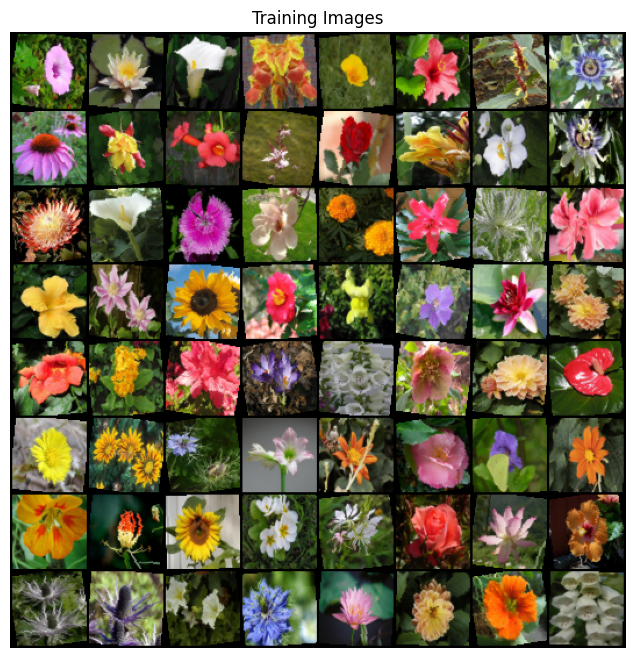

In [4]:
# Decide which device we want to run on
device = torch.device("cuda:0" if (torch.cuda.is_available() and ngpu > 0) else "cpu")

# Plot some training images
real_batch = next(iter(dataloader))
plt.figure(figsize=(8,8))
plt.axis("off")
plt.title("Training Images")
plt.imshow(np.transpose(vutils.make_grid(real_batch[0].to(device)[:64], padding=2, normalize=True).cpu(),(1,2,0)))

## Initialize parameters of Generator and Discriminator
This step for initializing the parameters of the generator and discriminator.
And define the structure of the dcGAN.

In [5]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [6]:
# Generator Code

class Generator(nn.Module):
    def __init__(self, ngpu):
        super(Generator, self).__init__()
        self.ngpu = ngpu
        self.main = nn.Sequential(
            # Input is Z (latent vector), going into a convolution
            nn.ConvTranspose2d( nz, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),
            
            #############################################################################
            # TODO: Implement the Upsampling Blocks.                                    #
            # You need to progressively increase the spatial size of the feature maps   #
            # while decreasing the number of channels.                                  #
            # The goal is to reach a feature map size compatible with the final output. #
            #############################################################################
            nn.ConvTranspose2d( ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            nn.ConvTranspose2d( ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            nn.ConvTranspose2d( ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            #############################################################################
            #                             End of your code                              #
            #############################################################################

            # Final output layer
            # State size: (ngf) x 32 x 32 -> (nc) x 64 x 64
            nn.ConvTranspose2d( ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, input):
        return self.main(input)

In [7]:
class Discriminator(nn.Module):
    def __init__(self, ngpu):
        super(Discriminator, self).__init__()
        self.ngpu = ngpu
        self.main = nn.Sequential(
            # Input is (nc) x 64 x 64
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            
            #############################################################################
            # TODO: Implement the Downsampling Blocks.                                  #
            # You need to progressively decrease the spatial size of the feature maps   #
            # while increasing the number of channels to extract features.              #
            #############################################################################
            nn.Conv2d( ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d( ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d( ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            #############################################################################
            #                             End of your code                              #
            #############################################################################

            # Final classification layer
            # State size: (ndf*8) x 4 x 4 -> 1
            nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.main(input)

In [8]:
# Create the generator
netG = Generator(ngpu).to(device)

if (device.type == 'cuda') and (ngpu > 1):
    netG = nn.DataParallel(netG, list(range(ngpu)))

netG.apply(weights_init)

print(netG)


# Create the Discriminator
netD = Discriminator(ngpu).to(device)

if (device.type == 'cuda') and (ngpu > 1):
    netD = nn.DataParallel(netD, list(range(ngpu)))

netD.apply(weights_init)

print(netD)

Generator(
  (main): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (13): Tanh()
  )
)


In [9]:

# Fixed noise vector for observing generator's progression
fixed_noise = torch.randn(64, nz, 1, 1, device=device)

# Optimizers use RMSProp, not Adam
optimizerD = optim.RMSprop(netD.parameters(), lr=lr)
optimizerG = optim.RMSprop(netG.parameters(), lr=lr)

## Training Step

In [10]:
# Training Loop
import torchvision.transforms as T
# Lists to keep track of progress
img_list = []
G_losses = []
D_losses = []
iters = 0
# masked_real_cpu = add_random_mask(real_cpu.clone())
print("Starting Training Loop...")
for epoch in range(num_epochs):
    for i, data in enumerate(dataloader, 0):
        
        ############################
        # (1) Update Critic (Discriminator)
        ###########################
        for p in netD.parameters():
            p.requires_grad = True

        ##################################################################################
        # TODO: Implement the Critic (Discriminator) Update Loop.                        #
        # 1. Clear gradients.                                                            #
        # 2. Compute the loss for real images (maximize D(x)).                           #
        # 3. Compute the loss for fake images (minimize D(G(z))).                        #
        # 4. Compute total Critic loss (Wasserstein distance approximation).             #
        # 5. Backpropagate and update Critic weights.                                    #
        # 6. Apply Weight Clipping to ensure Lipschitz constraint.                       #
        ##################################################################################
        for _ in range(n_critic):
            netD.zero_grad()
            # Train with real images
            real_images = data[0].to(device)
            batch_size = real_images.size(0)
            output_real = netD(real_images).view(-1)
            errD_real = -torch.mean(output_real)

            # Train with fake images
            noise = torch.randn(batch_size, nz, 1, 1, device=device)
            fake_images = netG(noise)
            output_fake = netD(fake_images.detach()).view(-1)
            errD_fake = torch.mean(output_fake)

            # Total loss and backpropagation
            errD = errD_real + errD_fake
            errD.backward()
            optimizerD.step()

            # Weight clipping
            for p in netD.parameters():
                p.data.clamp_(-clip_value, clip_value)
        ##################################################################################
        #                                 End of your code                               #
        ##################################################################################


        ############################
        # (2) Update Generator
        ###########################
        for p in netD.parameters():
            p.requires_grad = False

        netG.zero_grad()
        
        ##################################################################################
        # TODO: Implement the Generator Update Logic.                                    #
        # 1. Generate fake images from noise.                                            #
        # 2. Compute the Generator loss.                                                 #
        #    (The Generator wants to maximize D(G(z)), which means minimizing -D(G(z))). #
        # 3. Backpropagate and update Generator weights.                                 #
        ##################################################################################
        noise = torch.randn(batch_size, nz, 1, 1, device=device)
        fake_images = netG(noise)
        output = netD(fake_images).view(-1)
        errG = -torch.mean(output)
        errG.backward()
        optimizerG.step()
        ##################################################################################
        #                                 End of your code                               #
        ##################################################################################


        # Output training status
        if i % 50 == 0:
            print('[%d/%d][%d/%d]\tLoss_D: %.4f\tLoss_G: %.4f'
                  % (epoch, num_epochs, i, len(dataloader),
                     errD.item(), errG.item()))

        # Save loss values for later plotting
        G_losses.append(errG.item())
        D_losses.append(errD.item())

        # Check generator's performance periodically
        if (iters % 500 == 0) or ((epoch == num_epochs-1) and (i == len(dataloader)-1)):
            with torch.no_grad():
                fake = netG(fixed_noise).detach().cpu()
            img_list.append(vutils.make_grid(fake, padding=2, normalize=True))

        iters += 1


Starting Training Loop...


[0/500][0/32]	Loss_D: -0.0256	Loss_G: -0.4875


[1/500][0/32]	Loss_D: -0.2398	Loss_G: -0.3750


[2/500][0/32]	Loss_D: -0.3150	Loss_G: -0.3402


[3/500][0/32]	Loss_D: -0.3388	Loss_G: -0.3334


...

[495/500][0/32]	Loss_D: -0.1035	Loss_G: -0.4118


[496/500][0/32]	Loss_D: -0.0695	Loss_G: -0.3869


[497/500][0/32]	Loss_D: -0.0624	Loss_G: -0.5920


[498/500][0/32]	Loss_D: -0.1002	Loss_G: -0.5214


[499/500][0/32]	Loss_D: -0.0677	Loss_G: -0.5594


In [11]:

weights_dir = './model_weight/'
if not os.path.exists(weights_dir):
    os.makedirs(weights_dir)


torch.save(netG.state_dict(), os.path.join(weights_dir, 'Generator_weights.pth'))
torch.save(netD.state_dict(), os.path.join(weights_dir, 'Discriminator_weights.pth'))

print("model weight save to 'model_weight/'")

model weight save to 'model_weight/'


## Create fake dataset for calculating FID scores
FID scores use to evaluate the similarity between two datasets.

In [12]:
# Generate new images and save them
noise = torch.randn(8189, nz, 1, 1, device=device)

netG.eval()
with torch.no_grad():
    fake = netG(noise)


output_dir = './GENIMG/'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

for j in range(fake.size(0)):
    transform = T.Compose([T.Normalize(mean=[-1, -1, -1], std=[2, 2, 2]), T.ToPILImage()])
    img = transform(fake[j].cpu())
    img.save('./GENIMG/fake' + str(j) + '.jpg')

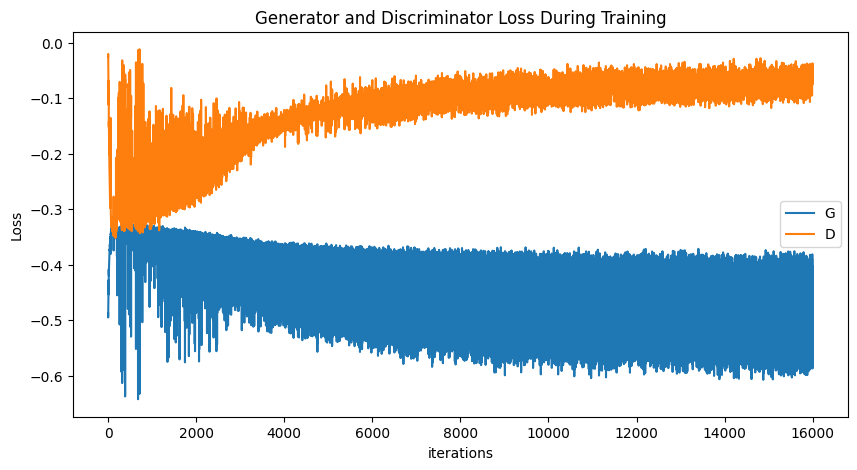

In [13]:
plt.figure(figsize=(10,5))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(G_losses,label="G")
plt.plot(D_losses,label="D")
plt.xlabel("iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [14]:
# Calculate FID
import torch
import torchvision
import torchvision.transforms as transforms
from pytorch_fid import fid_score
from PIL import Image
import os

# Resized original dataset path after 64x64 pixel adjustment
resized_folder_path = './resized_flowers102/'
# Generated image folder
generated_images_folder = './GENIMG/'
# Use Inception V3 model to calculate FID
inception_model = torchvision.models.inception_v3(pretrained=True)
fid_value = fid_score.calculate_fid_given_paths([resized_folder_path, generated_images_folder], batch_size=batch_size, device=device, dims=2048, num_workers=8)
print('FID value:', fid_value)

/home/at0842/aaronwu901225master.ai13/.conda/envs/all-test/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/at0842/aaronwu901225master.ai13/.conda/envs/all-test/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


  0%|          | 0/33 [00:00<?, ?it/s]

  3%|▎         | 1/33 [00:00<00:26,  1.20it/s]

  6%|▌         | 2/33 [00:01<00:18,  1.69it/s]

  9%|▉         | 3/33 [00:01<00:15,  1.94it/s]

...

 94%|█████████▍| 31/33 [00:13<00:00,  2.36it/s]

 97%|█████████▋| 32/33 [00:13<00:00,  2.36it/s]

100%|██████████| 33/33 [00:13<00:00,  2.91it/s]

100%|██████████| 33/33 [00:14<00:00,  2.36it/s]

FID value: 68.05369307643036


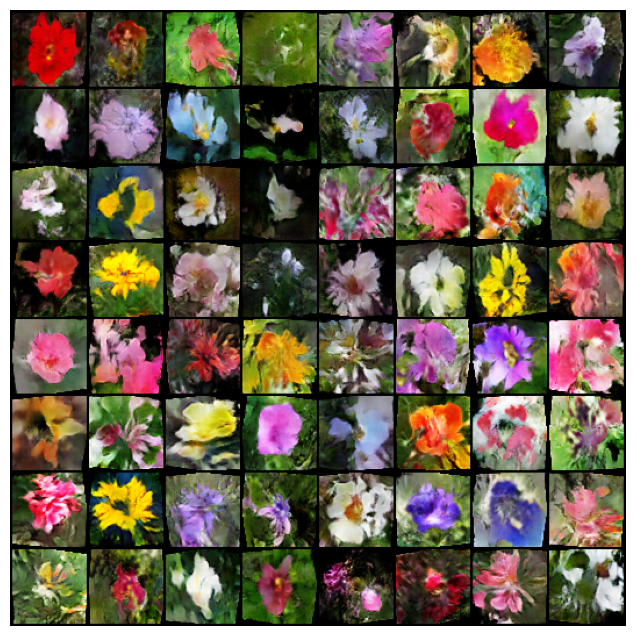

In [15]:
fig = plt.figure(figsize=(8,8))
plt.axis("off")
ims = [[plt.imshow(np.transpose(i,(1,2,0)), animated=True)] for i in img_list]

## Predict Result

Predict the labesl based on testing set. Upload to [Kaggle](https://www.kaggle.com/t/5bc3c73fc48947d19661212b05146a3c).

**How to upload**

1. To kaggle. Click "Submit Predictions"
2. Upload the result.csv
3. System will automaticlaly calculate the accuracy of 50% dataset and publish this result to leaderboard.

In [16]:
import pandas as pd

df_submission = pd.DataFrame({
    'id': [1], 
    'fid_score': [fid_value]
})

output_csv_path = 'result.csv'
df_submission.to_csv(output_csv_path, index=False)
